## 微观流变论文真正复现
直面问题！

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# 先得把画图的准备工作做好

def plot_rheology(data_list, name_list, xlim=None, ylim=None):
    """对比多组流变曲线的图像, data_list是多组<剪切速率, 粘度>对的列表, name_list是标签列表"""
    fig, ax = plt.subplots(figsize=(8, 6))
    for idx, data in enumerate(data_list):
        name = name_list[idx]
        shear_rate, viscosity = data
        ax.plot(shear_rate, viscosity, label=name)
    
    ax.set_xlabel('Shear rate (/s)')
    ax.set_ylabel('Viscosity (Pa·s)')
    ax.set_xscale('log')
    ax.set_yscale('log')
    if xlim:    ax.set_xlim(xlim)
    if ylim:    ax.set_ylim(ylim)
    ax.legend()
    plt.show()


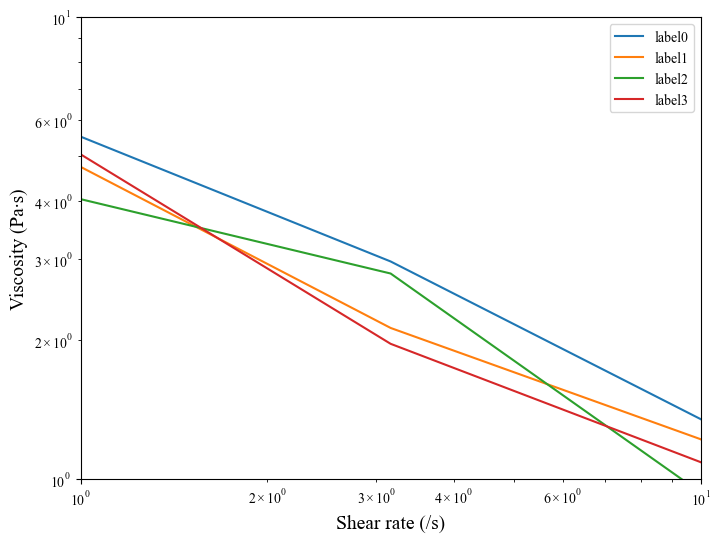

In [4]:
def generate_rheology_data(n_points=9, tau_min=0.1, tau_max=1000, seed=None):
    """
    生成流变学测试的随机数据 (tau, eta)

    参数:
        n_points: 数据点个数
        tau_min, tau_max: tau 的范围
        seed: 随机种子，用于重现结果

    返回:
        tau: numpy数组，指数增长
        eta: numpy数组，随 tau 递减（带随机噪声）
    """
    if seed is not None:
        np.random.seed(seed)

    log_tau = np.linspace(np.log10(tau_min), np.log10(tau_max), n_points)
    tau = 10 ** log_tau

    A = 5.0      # 调整此值可以改变曲线的整体高度
    b = 0.65     # 调整此值可以改变衰减速度
    eta_base = A * tau ** (-b)

    # 3. 添加随机噪声（对数正态噪声，使波动相对稳定）
    noise = np.random.lognormal(mean=0, sigma=0.1, size=n_points)
    eta = eta_base * noise

    return tau, eta

# 测试一下
test_data_list = [generate_rheology_data(seed=i) for i in range(4)]
test_name_list = [f'label{i}' for i in range(4)]

plot_rheology(test_data_list, test_name_list, xlim=(1,10), ylim=(1,10))

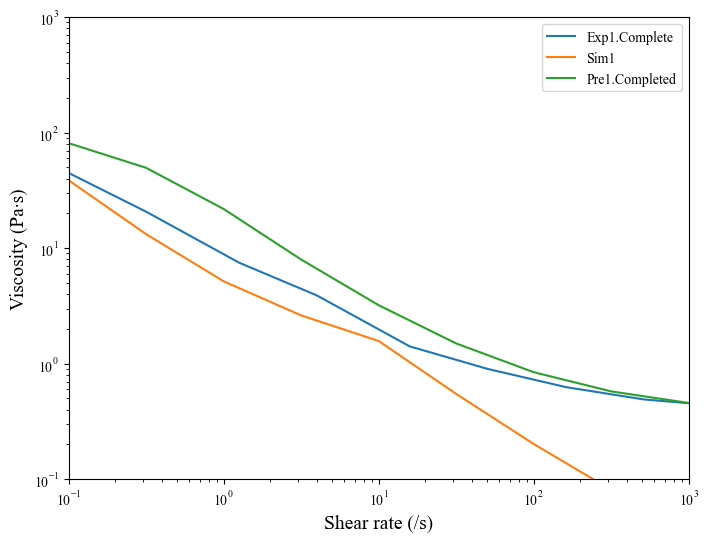

In [5]:
data = pd.read_excel('./data/figures_manuscript.xlsx', sheet_name='figure 5-a', skiprows=2)
data1 = data.iloc[:, 4:6].values # Exp1.Complete
data2 = pd.read_csv('./results/eta_gama.csv')
data2 = data2.values
data3 = data.iloc[:, [7,7+3]].values
plot_rheology([(dt[:, 0], dt[:, 1]) for dt in [data1, data2, data3]], ['Exp1.Complete', 'Sim1', 'Pre1.Completed'], xlim=(0.1,1000), ylim=(0.1,1000))

Uc(kbT): 6.41	 hc(e-9): 30.00	 Fc(e-12): 1.16	 k0: 1.95
Uc(kbT): 6.41	 hc(e-9): 30.00	 Fc(e-12): 1.16	 k0: 1.95
Uc(kbT): 7.06	 hc(e-9): 28.00	 Fc(e-12): 1.34	 k0: 1.92


/home/kurayingpat/project/01Slurry/00_MicroRheology/utils.py:178: RuntimeWarning: invalid value encountered in power
  eta_h = miu * (1 - phi_a / phi_m)**(-2.5*phi_m)
/home/kurayingpat/miniconda3/envs/ml/lib/python3.8/site-packages/scipy/optimize/_minpack_py.py:178: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


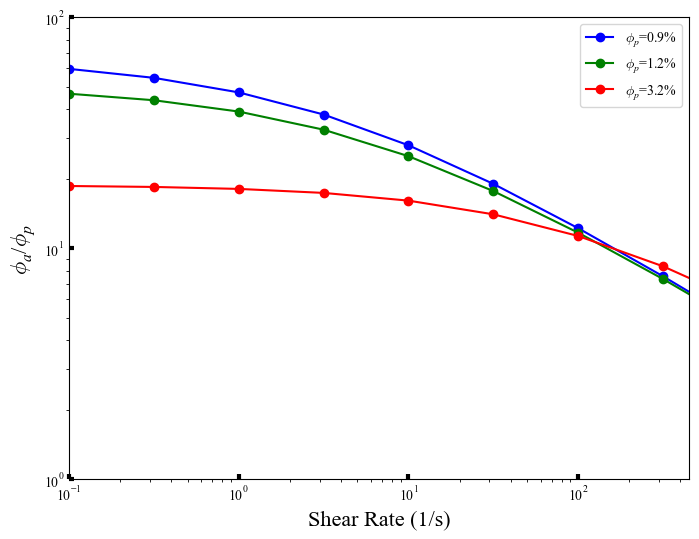

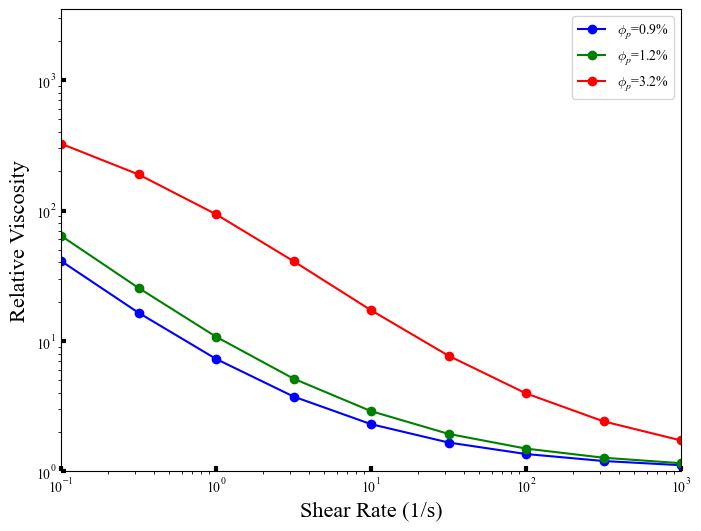

In [ ]:
from scipy.optimize import fsolve
from imgtools import PlotOverlay
import matplotlib.pyplot as plt
import numpy as np
from Ma.utils import cal_dlvo, cal_qq, cal_param, cal_viscosity


aa = 275e-9 # [m]
miu = 0.02
alpha = 0.9



k_list = [0.15, 0.15, 0.116] # 最关键的参数 **k** !!!
df = 1.6
dl = 1

qq_init_list = [aa * i for i in [0.01, 0.01, 0.01]]

phi_p_list = [0.9e-2, 1.2e-2, 3.2e-2]
L_list = [15e-9, 15e-9, 14e-9]

color_list = ['blue', 'green', 'red']

plotter_pa = PlotOverlay(ylabel='$\phi_a/\phi_p$', xlim=(0.1, 450), ylim=(1, 100))
plotter_viscosity = PlotOverlay(ylabel='Relative Viscosity', xlim=(0.1, 1000), ylim=(1, 3500))

for idx, phi_p in enumerate(phi_p_list):
    k = k_list[idx]
    L = L_list[idx]
    # L = 15e-9 # TODO: L并非定值, 后续需要修改
    c = color_list[idx]
    qq_init = qq_init_list[idx]


    list_pa = []
    list_gamma = []
    list_relative_viscosity = []



    list_x, list_y = cal_dlvo(L=L, Mw=5e5, aa=275e-9, is_check=False, is_plot=False)
    Uc, hc, Fc, k0 = cal_param(list_x, list_y, aa=aa, dx=2e-9, verbose=True, is_plot=False)

    
    for i in range(13):
        gm = i * 0.5 - 2
        gamma = 10**gm

        qq = fsolve(cal_qq, qq_init, args=(gamma, Fc, hc, k0, aa, phi_p, miu, alpha, k, df, dl),xtol=1e-13)
        phi_a = phi_p * (qq[0]/(k*aa))**(3-df)

        viscosity = cal_viscosity(alpha=alpha, gamma=gamma, Fc=Fc, hc=hc, k0=k0, aa=aa, phi_a=phi_a, phi_p=phi_p, df=df, dl=dl, miu=miu, verbose=False)

        list_pa.append(phi_a/phi_p)
        list_gamma.append(gamma)
        list_relative_viscosity.append(viscosity / miu)

    plotter_pa.add_data(list_gamma, list_pa, marker='o', linestyle='-', color=c, label=f'$\phi_p$={phi_p*100:.1f}%')
    plotter_viscosity.add_data(list_gamma, list_relative_viscosity, marker='o', linestyle='-', color=c, label=f'$\phi_p$={phi_p*100:.1f}%')

# plotter_viscosity.add_data(rawData['shear_rate'], rawData['rel_viscosity_09'], marker='s', linestyle='--', color=color_list[0], label='Exp$\phi_p=0.9$%')
# plotter_viscosity.add_data(rawData['shear_rate'], rawData['rel_viscosity_12'], marker='o', linestyle='--', color=color_list[1], label='Exp$\phi_p=1.2$%')
# plotter_viscosity.add_data(rawData['shear_rate'], rawData['rel_viscosity_32'], marker='v', linestyle='--', color=color_list[2], label='Exp$\phi_p=3.2$%')

# 添加原始数据

# 显示绘图
plotter_pa.show()
plotter_viscosity.show()   